In [1]:
%matplotlib ipympl

Effective fluxonium capacitance Cq_eff ≈ 16.14 fF
g0 443.7189175992708 MHz
Computing Fluxonium spectrum and matrix elements...


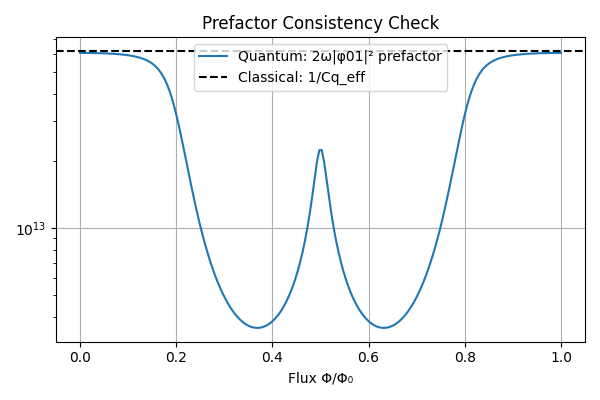

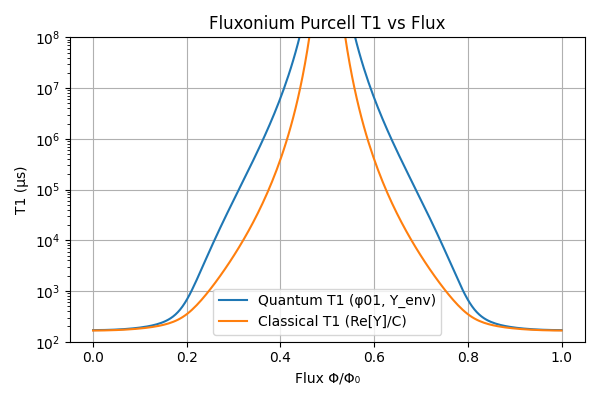

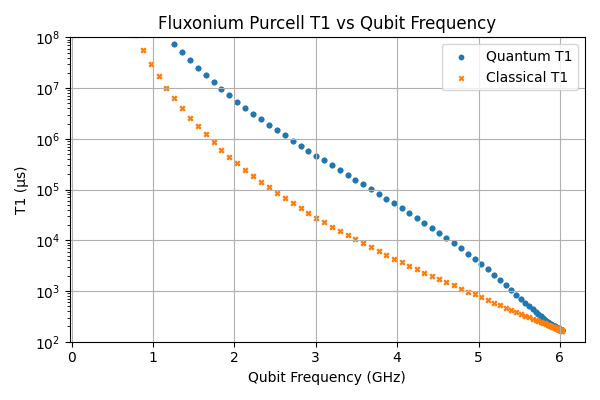

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi
from scipy.constants import h, hbar, e

# ============================================================================
# Classical resonator + coupling circuit (same structure as your transmon case)
# ============================================================================

# Resonator parameters
wr = 2 * pi * 9e9           # 9 GHz resonator
kappa = 2 * pi * 12.3e6     # linewidth

# Capacitive couplings
Cg = 1e-15                  # example 1 fF
Ck = 1e-15
Cr = 20e-15                 # resonator cap
Ctot_r = Cr + Ck + Cg
Lr = 1 / (wr**2 * Ctot_r)   # resonator inductance from wr

# Feedline impedance
Rfeed = 50.0


# ============================================================================
# Classical input admittance seen by the qubit
# ============================================================================

def Yin_numeric(w, Cq_eff):
    """
    Environment admittance from classical network:
    Qubit -- Cq_eff || [ Cg -- (Cr||Lr) -- Ck -- 50Ω ]
    fitting parameters:
        Cg   coupling cap to resonator
        Ck   coupling cap to feedline
    """
    jw = 1j * w
    Y_series = 1/(jw*Cg) + 1/( jw*Cr + 1/(jw*Lr) + 1/( Rfeed + 1/(jw*Ck) ) )
    return jw*Cq_eff + 1 / Y_series


# ============================================================================
# FLUXONIUM PARAMETERS
# ============================================================================

try:
    import scqubits as scq
except ImportError:
    raise RuntimeError("Install scqubits first: pip install scqubits")

# Fluxonium energies (GHz)
E_l_GHz = 0.6
E_c_GHz = 1.2
E_j_GHz = 5.0
cutoff   = 80

# Flux sweep
phi_list = np.linspace(0.0, 1.0, 200)

# Convert EC → effective qubit capacitance
EC_Hz = E_c_GHz * 1e9
Cq_eff = e**2 / (2 * h * EC_Hz)      # Farad
print("Effective fluxonium capacitance Cq_eff ≈ %.2f fF" % (Cq_eff*1e15))

print("g0",0.5* Cg*wr/np.sqrt((Cq_eff+Cg)*(Ctot_r+Cg+Ck)) / (2*pi*1e6), "MHz")

# ============================================================================
# Functions: compute ω01(Φ) and φ01(Φ)
# ============================================================================

def fluxonium_w01_phi01(flux):
    """
    Compute:
        - ω01(Φ)  angular frequency
        - φ01(Φ)  matrix element of φ operator
    """
    qubit = scq.Fluxonium(
        EJ=E_j_GHz,
        EC=E_c_GHz,
        EL=E_l_GHz,
        flux=flux,
        cutoff=cutoff
    )

    evals, evecs = qubit.eigensys(evals_count=2)
    v0, v1 = evecs[:, 0], evecs[:, 1]

    # eigenvalues in GHz → angular frequency
    w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

    # φ operator exists for Fluxonium (unlike TunableTransmon)
    phi_op = qubit.phi_operator()

    phi01 = (v0.conj().T @ phi_op @ v1).item()

    return w01, phi01


# ============================================================================
# Sweep Flux with Fluxonium model
# ============================================================================

w01_list  = np.zeros_like(phi_list)
phi01_list = np.zeros_like(phi_list, dtype=complex)

print("Computing Fluxonium spectrum and matrix elements...")
for i, flux in enumerate(phi_list):
    w01_list[i], phi01_list[i] = fluxonium_w01_phi01(flux)


# ============================================================================
# Classical Purcell from admittance: Γ_class = Re[Y]/Cq_eff
# ============================================================================

Gamma_class = np.array([
    np.real(Yin_numeric(w01_list[i], Cq_eff)) / Cq_eff
    for i in range(len(phi_list))
])
T1_class = 1 / Gamma_class


# ============================================================================
# Quantum Purcell rate:
# Γ = prefactor * 2 ω_q |φ01|² Re[Y_env]
# Y_env = Yin - jw Cq_eff
# ============================================================================

def Y_env(w, Cq_eff):
    return Yin_numeric(w, Cq_eff) - 1j*w*Cq_eff

prefactor = hbar / (4*e**2)          # SI Ohms

Gamma_phi = np.zeros_like(phi_list)
for i in range(len(phi_list)):
    wq = w01_list[i]
    phi01 = phi01_list[i]
    ReY = np.real(Y_env(wq, Cq_eff))
    Gamma_phi[i] = prefactor * 2 * wq * (np.abs(phi01)**2) * ReY

T1_phi = 1 / Gamma_phi


# ============================================================================
# Consistency check:
#   classical prefactor 1/Cq_eff  vs  quantum prefactor 2ω|φ01|²
# ============================================================================

quant_pref = prefactor * 2 * w01_list * np.abs(phi01_list)**2
class_pref = 1 / Cq_eff


plt.figure(figsize=(6,4))
plt.plot(phi_list, quant_pref, label="Quantum: 2ω|φ01|² prefactor")
plt.axhline(class_pref, color='k', linestyle='--', label="Classical: 1/Cq_eff")
plt.yscale("log")
plt.grid()
plt.xlabel("Flux Φ/Φ₀")
plt.title("Prefactor Consistency Check")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================================
# T1 vs Flux
# ============================================================================

plt.figure(figsize=(6,4))
plt.plot(phi_list, T1_phi*1e6, label="Quantum T1 (φ01, Y_env)")
plt.plot(phi_list, T1_class*1e6, label="Classical T1 (Re[Y]/C)")
plt.yscale("log")
plt.ylim(1e2, 1e8)
plt.grid()
plt.xlabel("Flux Φ/Φ₀")
plt.ylabel("T1 (µs)")
plt.title("Fluxonium Purcell T1 vs Flux")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================================
# T1 vs Frequency
# ============================================================================

plt.figure(figsize=(6,4))
plt.scatter(w01_list/(2*pi*1e9), T1_phi*1e6, label="Quantum T1", s=10)
plt.scatter(w01_list/(2*pi*1e9), T1_class*1e6, label="Classical T1", marker="x", s=10)
plt.yscale("log")
plt.ylim(1e2, 1e8)
plt.grid()
plt.xlabel("Qubit Frequency (GHz)")
plt.ylabel("T1 (µs)")
plt.title("Fluxonium Purcell T1 vs Qubit Frequency")
plt.legend()
plt.tight_layout()
plt.show()
